In [1]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure
from scipy.stats import exponweib
import seaborn as sns
from scipy.optimize import curve_fit


In [2]:
preds_dir = '../../preds/'
dataset_dir = '../../data/all_years_merged_era5.nc'

SCALING_FACTOR = 4
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'
years = [i for i in range(1984, 2024)]
print(years)


[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [3]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)



In [4]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)


In [5]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)


In [6]:
def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
        field = torch.load(files_dir + file, weights_only=False)
            
        #print("Current file: ", file)   
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            
            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            
        elif file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names


In [7]:
longitudes = eval_split.longitude.values[:32]
latitudes = eval_split.latitude.values[:32]
print(longitudes[0], longitudes[-1])    
print(latitudes[0], latitudes[-1])

6.45 14.2
55.16 47.41


In [15]:

ws_dict_north = {year: {} for year in years}
ws_dict_south = {year: {} for year in years}    
for year in years:
        eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)
        ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale, 
                                                lr_ws=lr_wind_speeds, 
                                                gt_ws=ground_truth_wind_speeds)
        
        edsr = ws_fields[names.index('EDSR')]
        baseline = ws_fields[names.index('Bicubic Interpolation')]
        
        # split the data in north and south 
        north = slice(0, 16)
        south = slice(16, 32)
        ws_dict_north[year]['EDSR'] = edsr[:, north, :]
        ws_dict_north[year]['Bicubic'] = baseline[:, north, :]
        ws_dict_north[year]['Ground Truth'] = ground_truth_wind_speeds[:, north, :]
        ws_dict_south[year]['EDSR'] = edsr[:, south, :]
        ws_dict_south[year]['Bicubic'] = baseline[:, south, :]
        ws_dict_south[year]['Ground Truth'] = ground_truth_wind_speeds[:, south, :]
        


In [ ]:
def get_metrics_over_time(years, ws_dict):
    mses = {'EDSR': [], 'Bicubic': []}
    maes = {'EDSR': [], 'Bicubic': []}
    mse_skill_scores = []
    mae_skill_scores = []
    for year in years:
        edsr, baseline = ws_dict[year]['EDSR'], ws_dict[year]['Bicubic']
        ground_truth_wind_speeds = ws_dict[year]['Ground Truth']
        
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
        mse_skill_scores.append(get_skill_score(mse_edsr, mse_baseline))
        mae_skill_scores.append(get_skill_score(mae_edsr, mae_baseline))
        
        mses['EDSR'].append(mse_edsr)
        mses['Bicubic'].append(mse_baseline)
        maes['EDSR'].append(mae_edsr)
        maes['Bicubic'].append(mae_baseline)
        
    return mses, maes, mse_skill_scores, mae_skill_scores



def plot_metrics_over_time(years, mses_north, mses_south, maes_north, maes_south):
    fig, ax = plt.subplots(2, 1, figsize=(12, 10))
    ax[0].plot(years, mses_north['EDSR'], 'o-', label='North', color='blue')
    ax[0].plot(years, mses_south['EDSR'], 'o-', label='South', color='orange')
    ax[0].set_title('MSE of north and south regions')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('MSE')
    ax[0].legend()
    ax[0].grid(True)
    ax[1].plot(years, maes_north['EDSR'], 'o-', label='North', color='blue')
    ax[1].plot(years, maes_south['EDSR'], 'o-', label='South', color='orange')
    ax[1].set_title('MAE of north and south regions')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('MAE')
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()
   
def plot_skill_scores(years, mse_ss, mae_ss):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(years, mse_ss, 'o-', label='MSE Skill Score ', color='blue')
    ax[0].set_title('MSE Skill Score between North and South')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Skill Score')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(years, mae_ss, 'o-', label='MAE Skill Score ', color='orange')
    ax[1].set_title('MAE Skill Score between North and South')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Skill Score')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

def compare_skill_score(years, mse_ss_north, mse_ss_south, mae_ss_north, mae_ss_south):
    fig, ax = plt.subplots(2, 1, figsize=(12, 10))
    ax[0].plot(years, mse_ss_north, 'o-', label='North', color='blue')
    ax[0].plot(years, mse_ss_south, 'o-', label='South', color='orange')
    ax[0].set_title('MSE Skill Score of north and south regions')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Skill Score')
    ax[0].legend()
    ax[0].grid(True)
    ax[1].plot(years, mae_ss_north, 'o-', label='North', color='blue')
    ax[1].plot(years, mae_ss_south, 'o-', label='South', color='orange')
    ax[1].set_title('MAE Skill Score of north and south regions')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Skill Score')
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()

In [31]:
mse_north, mae_north, mse_skill_scores_north, mae_skill_scores_north = get_metrics_over_time(years, ws_dict_north)
mse_south, mae_south, mse_skill_scores_south, mae_skill_scores_south = get_metrics_over_time(years, ws_dict_south)

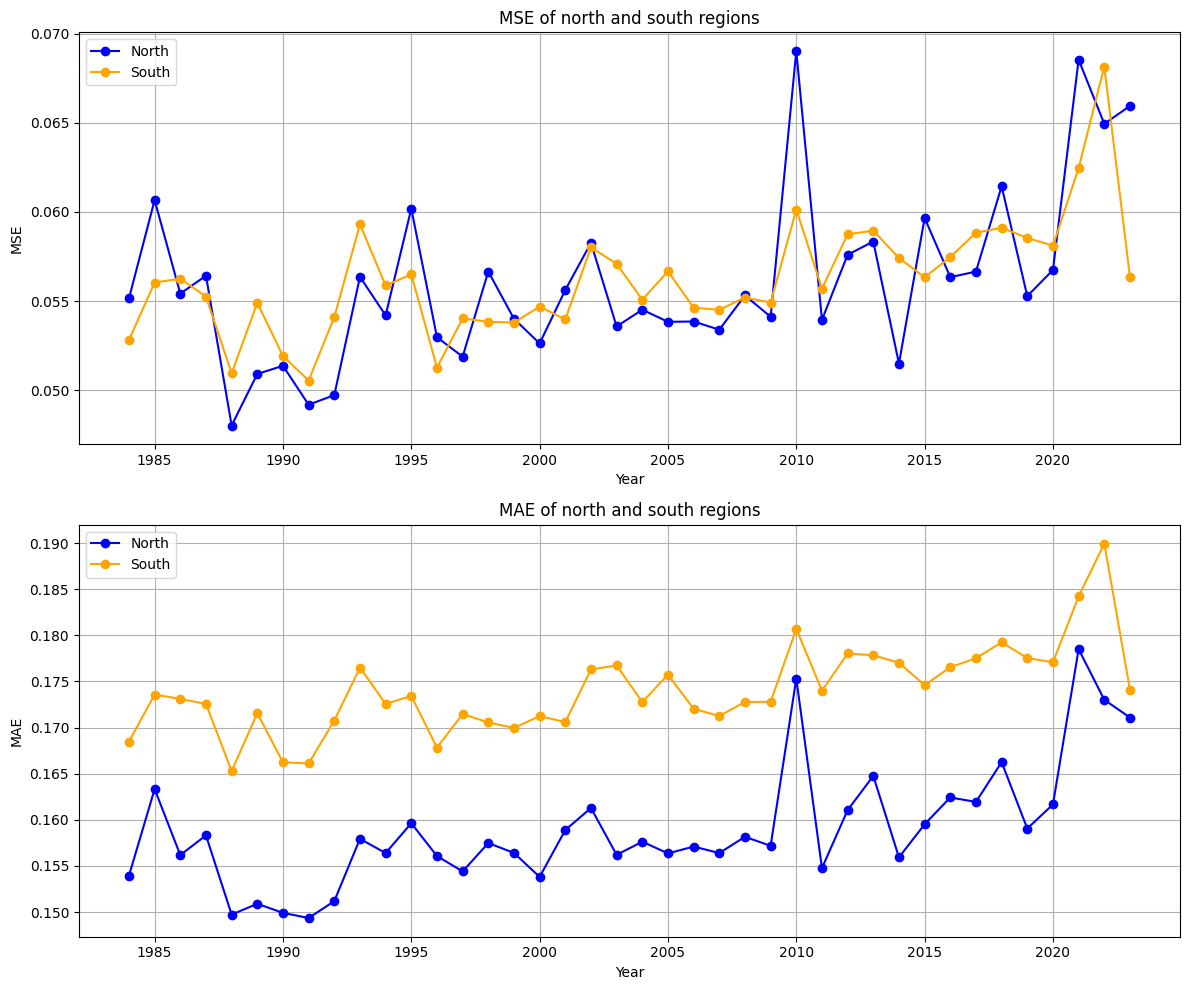

In [32]:
plot_metrics_over_time(years, mse_north, mse_south, mae_north, mae_south)



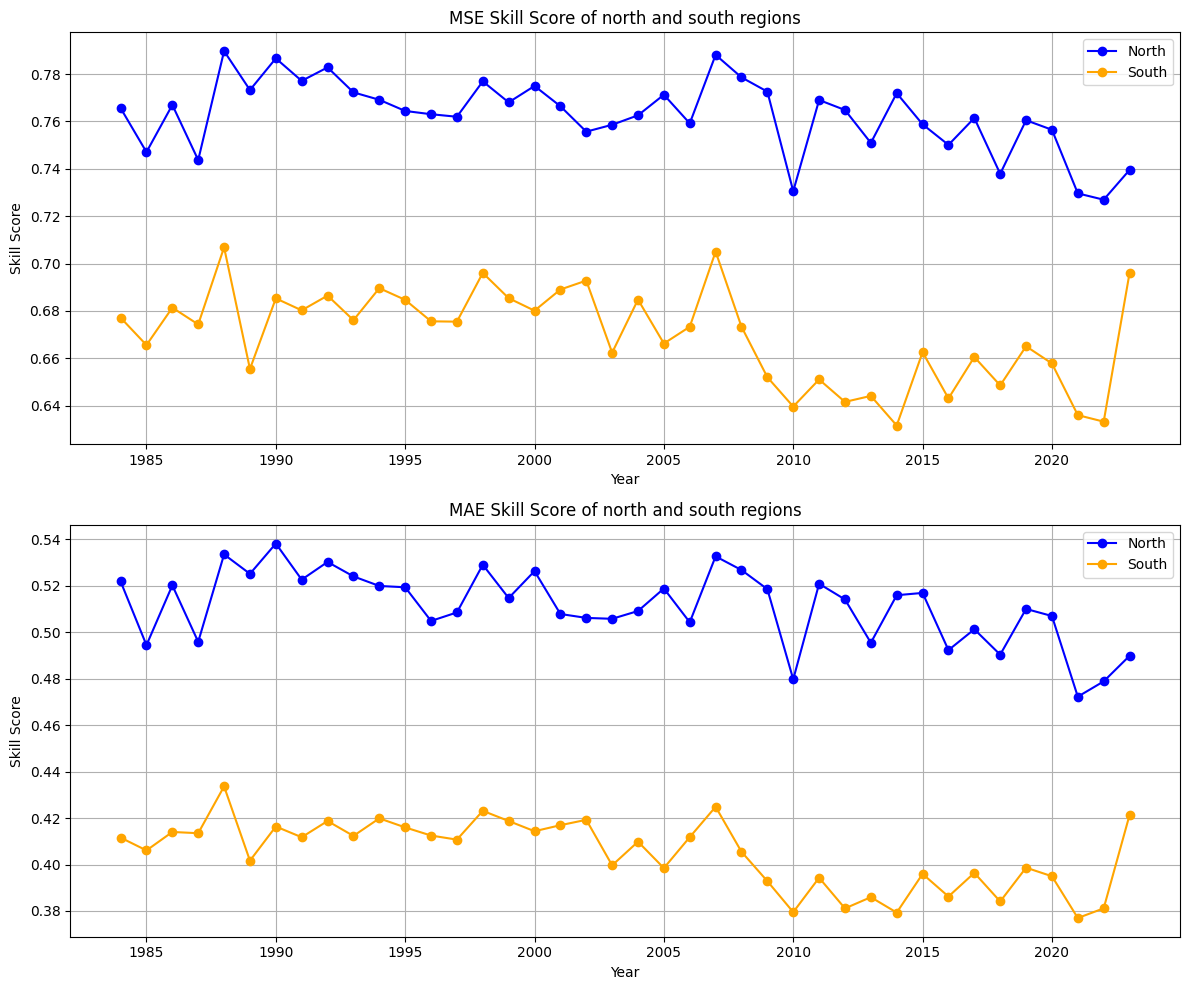

In [33]:
compare_skill_score(years, mse_skill_scores_north, mse_skill_scores_south, mae_skill_scores_north, mae_skill_scores_south)

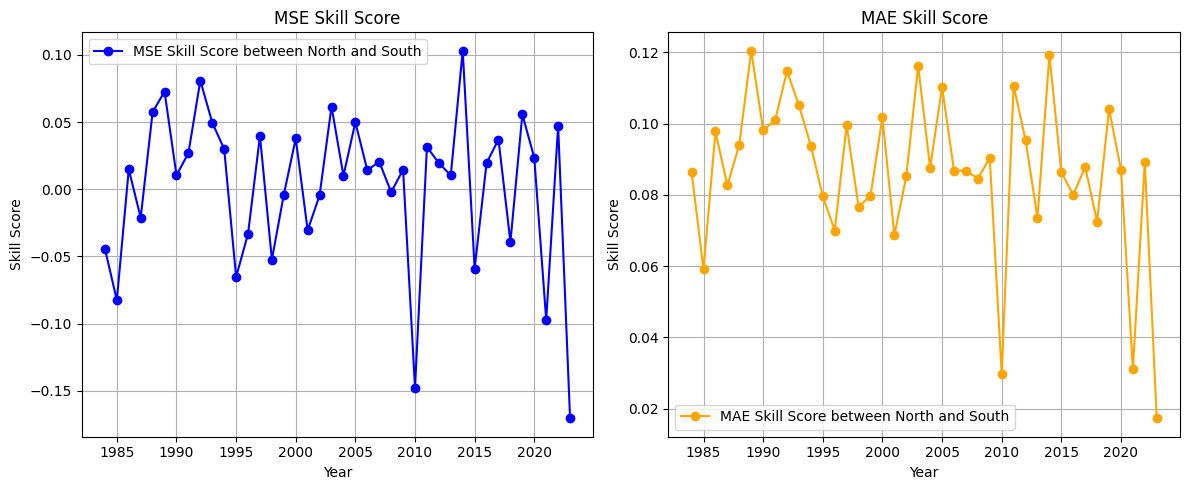

In [34]:
# get skill score between north and south

def north_south_skill_score(mse_north, mse_south, mae_north, mae_south):
    mse_skill_score = []
    mae_skill_score = []
    for i in range(len(mse_north['EDSR'])):
        mse_skill_score.append(get_skill_score(mse_north['EDSR'][i], mse_south['EDSR'][i]))
        mae_skill_score.append(get_skill_score(mae_north['EDSR'][i], mae_south['EDSR'][i]))
    return mse_skill_score, mae_skill_score

mse_skill_score2, mae_skill_score2 = north_south_skill_score(mse_north, mse_south, mae_north, mae_south)
plot_skill_scores(years, mse_skill_score2, mae_skill_score2)